=== STEP 1: Loading Dataset & Remapping Classes ===
Feature matrix shape: (569, 30)
Class distribution:
malignant
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

=== STEP 2: Data Audit ===
                   dtype  missing  unique        min        max
mean radius      float64        0     456    6.98100    28.1100
mean texture     float64        0     479    9.71000    39.2800
mean perimeter   float64        0     522   43.79000   188.5000
mean area        float64        0     539  143.50000  2501.0000
mean smoothness  float64        0     474    0.05263     0.1634
Duplicate predictor rows: 0

=== STEP 3: Splitting & Locking Test Set ===
Training set: (455, 30) | Test set: (114, 30)
Train Malignant Prevalence: 0.3736
Test Malignant Prevalence:  0.3684

=== STEP 4: Tuning & Pruning Decision Tree (CART) ===
Selected ccp_alpha: 0.010509
Best Training CV ROC-AUC: 0.9477

=== STEP 5: Model Comparison on Training Set (5-Fold CV) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

              Model  CV ROC-AUC Mean  CV ROC-AUC Std  CV Sensitivity Mean  CV PR-AUC Mean  CV Balanced Acc Mean
      Random Forest         0.988958        0.006558             0.935294        0.987680              0.955366
Tuned & Pruned CART         0.947730        0.031126             0.917647        0.898852              0.937771
         Basic CART         0.917234        0.037542             0.894118        0.845327              0.917234
     Dummy Baseline         0.500000        0.000000             0.000000        0.373626              0.500000

=== STEP 6: Out-of-Fold Threshold Optimization ===
Selected Operating Decision Threshold: 0.8500

=== STEP 7: Final Test Set Evaluation ===
  threshold         : 0.8500
  TN                : 69
  FP                : 3
  FN                : 5
  TP                : 37
  accuracy          : 0.9298
  balanced_accuracy : 0.9196
  sensitivity       : 0.8810
  specificity       : 0.9583
  precision_ppv     : 0.9250
  npv               : 0.932

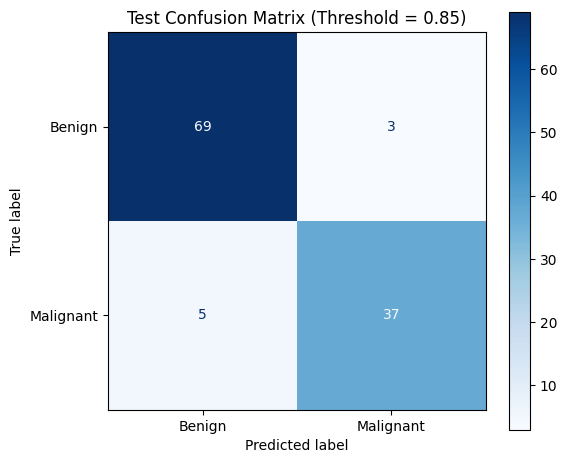

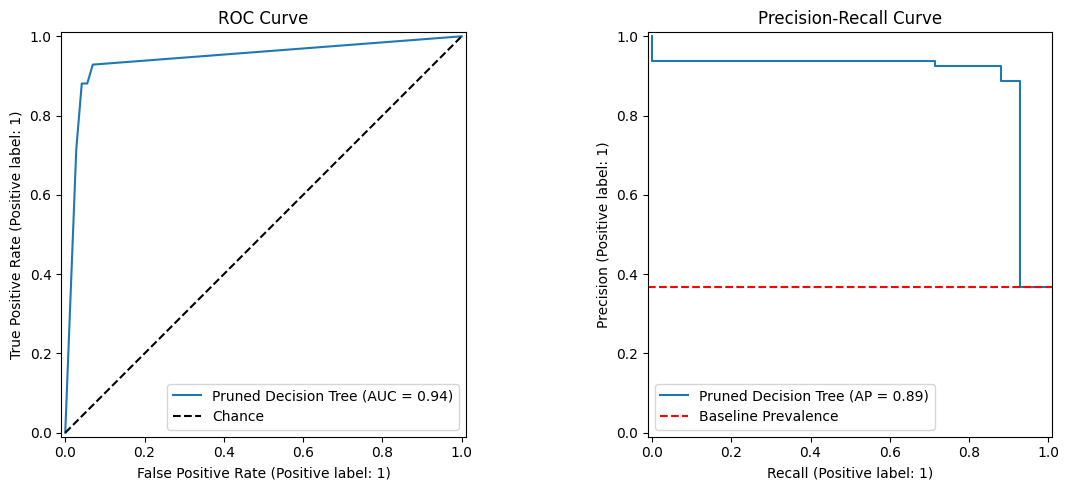

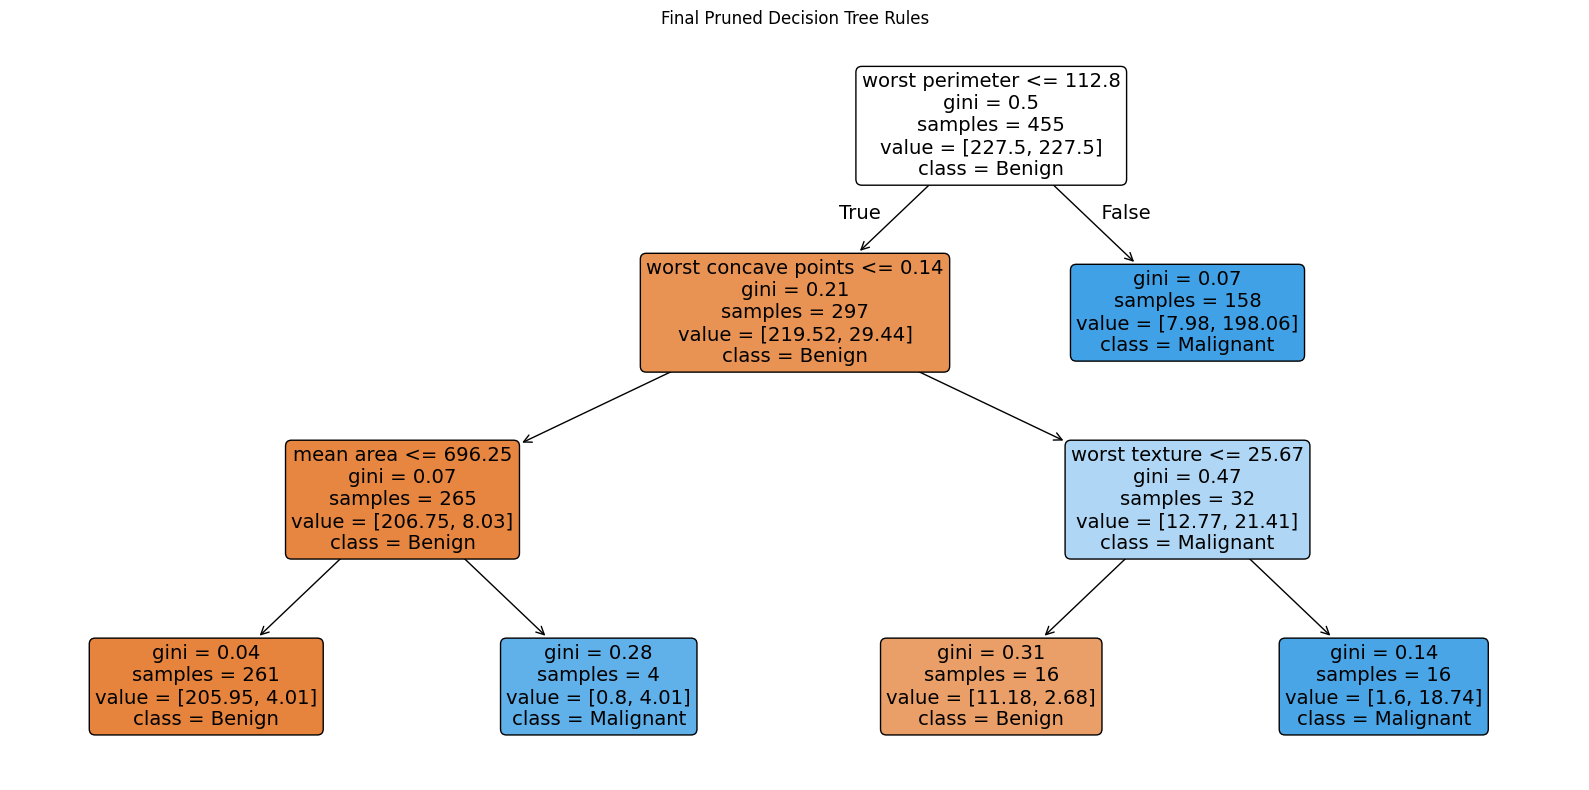

--- Decision Rules Extraction ---
|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.14
|   |   |--- mean area <= 696.25
|   |   |   |--- class: 0
|   |   |--- mean area >  696.25
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.67
|   |   |   |--- class: 0
|   |   |--- worst texture >  25.67
|   |   |   |--- class: 1
|--- worst perimeter >  112.80
|   |--- class: 1


=== STEP 9: Exporting Artifacts ===
 Artifacts saved successfully:
  - lab02_decision_tree_artifact.joblib
  - lab02_test_metrics.csv
  - lab02_cv_results.csv


In [ ]:
import os
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42


print("=== STEP 1: Loading Dataset & Remapping Classes ===")
raw_data = load_breast_cancer(as_frame=True)
X = raw_data.data.copy()


y = (raw_data.target == 0).astype(int)
y.name = "malignant"

print(f"Feature matrix shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'})}")


print("\n=== STEP 2: Data Audit ===")
audit_df = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique": X.nunique(),
    "min": X.min(numeric_only=True),
    "max": X.max(numeric_only=True)
})
print(audit_df.head())
print(f"Duplicate predictor rows: {X.duplicated().sum()}")
assert "target" not in X.columns and "malignant" not in X.columns, "Target leakage detected!"


print("\n=== STEP 3: Splitting & Locking Test Set ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"Train Malignant Prevalence: {y_train.mean():.4f}")
print(f"Test Malignant Prevalence:  {y_test.mean():.4f}")

scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}


print("\n=== STEP 4: Tuning & Pruning Decision Tree (CART) ===")
tree_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas[:-1])

alpha_grid = {
    "model__ccp_alpha": ccp_alphas,
    "model__class_weight": [None, "balanced"]
}

prune_search = GridSearchCV(
    tree_pipe,
    param_grid=alpha_grid,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
prune_search.fit(X_train, y_train)

print(f"Selected ccp_alpha: {prune_search.best_params_['model__ccp_alpha']:.6f}")
print(f"Best Training CV ROC-AUC: {prune_search.best_score_:.4f}")


print("\n=== STEP 5: Model Comparison on Training Set (5-Fold CV) ===")
models = {
    "Dummy Baseline": DummyClassifier(strategy="prior"),
    "Basic CART": DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
    "Tuned & Pruned CART": prune_search.best_estimator_,
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv_results_list = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring_metrics)
    cv_results_list.append({
        "Model": name,
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": scores["test_roc_auc"].std(),
        "CV Sensitivity Mean": scores["test_recall"].mean(),
        "CV PR-AUC Mean": scores["test_pr_auc"].mean(),
        "CV Balanced Acc Mean": scores["test_balanced_accuracy"].mean()
    })

cv_summary_df = pd.DataFrame(cv_results_list).sort_values("CV ROC-AUC Mean", ascending=False)
print(cv_summary_df.to_string(index=False))


print("\n=== STEP 6: Out-of-Fold Threshold Optimization ===")
selected_model_pipeline = prune_search.best_estimator_

oof_probs = cross_val_predict(
    selected_model_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_candidates = []
for thresh in np.linspace(0.05, 0.95, 181):
    pred = (oof_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    threshold_candidates.append((thresh, sens, spec))

thresh_df = pd.DataFrame(threshold_candidates, columns=["threshold", "sensitivity", "specificity"])

TARGET_SENSITIVITY = 0.90
feasible_thresholds = thresh_df[thresh_df["sensitivity"] >= TARGET_SENSITIVITY]
selected_threshold = feasible_thresholds.sort_values("specificity", ascending=False).iloc[0]["threshold"]

print(f"Selected Operating Decision Threshold: {selected_threshold:.4f}")


print("\n=== STEP 7: Final Test Set Evaluation ===")
def evaluate_model(y_true, probas, threshold=0.50):
    preds = (probas >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    return {
        "threshold": threshold,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "sensitivity": recall_score(y_true, preds, zero_division=0),
        "specificity": spec,
        "precision_ppv": precision_score(y_true, preds, zero_division=0),
        "npv": npv,
        "f1": f1_score(y_true, preds, zero_division=0),
        "mcc": matthews_corrcoef(y_true, preds),
        "roc_auc": roc_auc_score(y_true, probas),
        "pr_auc": average_precision_score(y_true, probas),
        "brier_score": brier_score_loss(y_true, probas)
    }

final_fitted_model = selected_model_pipeline.fit(X_train, y_train)
test_probs = final_fitted_model.predict_proba(X_test)[:, 1]
test_results = evaluate_model(y_test, test_probs, selected_threshold)

for metric, val in test_results.items():
    print(f"  {metric:<18}: {val:.4f}" if isinstance(val, float) else f"  {metric:<18}: {val}")


print("\n=== STEP 8: Visualizations & Interpretability ===")

test_preds = (test_probs >= selected_threshold).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds,
    display_labels=["Benign", "Malignant"],
    cmap="Blues", values_format="d", ax=ax
)
plt.title(f"Test Confusion Matrix (Threshold = {selected_threshold:.2f})")
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_probs, name="Pruned Decision Tree", ax=ax1)
ax1.plot([0, 1], [0, 1], "k--", label="Chance")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_predictions(y_test, test_probs, name="Pruned Decision Tree", ax=ax2)
ax2.axhline(y_test.mean(), color="red", linestyle="--", label="Baseline Prevalence")
ax2.set_title("Precision-Recall Curve")
ax2.legend()
plt.tight_layout()
plt.show()

fitted_tree_clf = final_fitted_model.named_steps["model"]
plt.figure(figsize=(16, 8))
plot_tree(
    fitted_tree_clf,
    feature_names=X_train.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    precision=2
)
plt.title("Final Pruned Decision Tree Rules")
plt.tight_layout()
plt.show()

tree_rules_text = export_text(fitted_tree_clf, feature_names=list(X_train.columns))
print("--- Decision Rules Extraction ---")
print(tree_rules_text[:2000])


print("\n=== STEP 9: Exporting Artifacts ===")

artifact_payload = {
    "model": final_fitted_model,
    "threshold": float(selected_threshold),
    "positive_class": "malignant",
    "feature_names": list(X_train.columns),
    "random_state": RANDOM_STATE,
    "test_metrics": test_results,
    "software": {
        "python": platform.python_version(),
        "scikit_learn": joblib.__version__
    },
    "intended_use": "Educational predictive-analytics laboratory only",
    "prohibited_use": "Clinical diagnosis, treatment, triage, or patient management"
}

joblib.dump(artifact_payload, "lab02_decision_tree_artifact.joblib")
pd.DataFrame([test_results]).to_csv("lab02_test_metrics.csv", index=False)
cv_summary_df.to_csv("lab02_cv_results.csv", index=False)

print(" Artifacts saved successfully:")
print("  - lab02_decision_tree_artifact.joblib")
print("  - lab02_test_metrics.csv")
print("  - lab02_cv_results.csv")